In [6]:
#Step 1: Import Required Libraties
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:

X = df[['displacement']]
y = df['mpg']

print("Missing values in Displacement: ",X.isnull().sum())
print("Missing Values in MPG: ",y.isnull().sum())

Missing values in Displacement:  displacement    0
dtype: int64
Missing Values in MPG:  0


In [9]:
data =df[['displacement' , 'mpg']].dropna()

X = df[['displacement']]
y = df['mpg']

print("Feature: ")
print(X.head())

print("\nTarget:")
print(y.head())

Feature: 
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


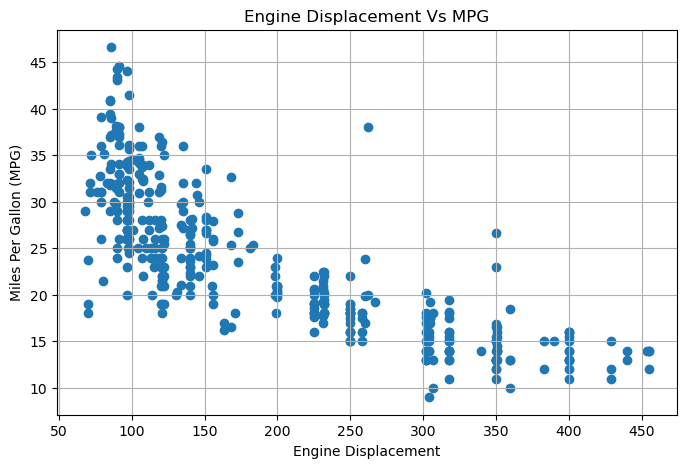

In [10]:
plt.figure(figsize =(8,5))

plt.scatter(X,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Displacement Vs MPG")

plt.grid(True)
plt.show()

In [11]:
#split The dataset

X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training Samples: ",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples:  318
Testing Samples: 80


In [14]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [15]:
#Calculate MSE

mse_linear = mean_squared_error(y_test , y_pred_linear)

r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression Results")
print("--------------------------")
print("MSE: ",mse_linear)
print("R-Squared:",r2_linear)

Linear Regression Results
--------------------------
MSE:  18.102543998358946
R-Squared: 0.6633114869465595


In [39]:
#Store Results
result=[]

#Store polynomial model for plotting
polynomial_model={}

#Add Linear Regresstion results
result.append({
    'Model' : 'Linear Regression',
    'Degree': 1,
    'MSE' : mse_linear,
    'R-Squared' : r2_linear
})

#Try polynomial degree from 2 to 5
for degree in range(2,6):

    #Create polynomial Features
    poly = PolynomialFeatures(degree=degree)

    #Transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    #Create Linear Regression
    poly_model = LinearRegression()

    #Train Polynomial Regression model
    poly_model.fit(X_train_poly, y_train)

    #Make Predictions
    y_pred_poly = poly_model.predict(X_test_poly)

    #Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    result.append({
        'Model' : 'Polynomial Regression',
        'Degree': degree,
        'MSE' : mse,
        'R-Squared' : r2
    })

    #Store model and polynomial transfomer
    polynomial_model[degree] = {
            'poly' : poly,
            'model' : poly_model
    }

In [24]:
results_df = pd.DataFrame(result)
results_df

,Model,Degree,MSE,R-Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


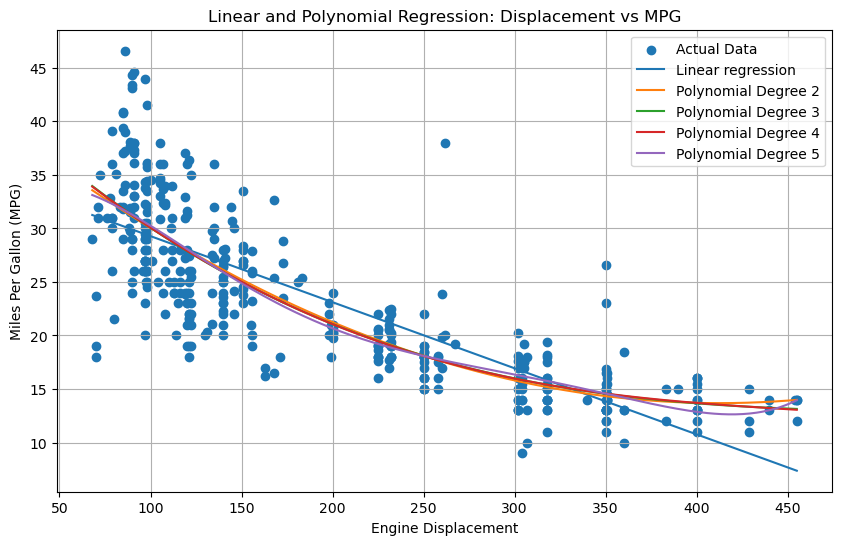

In [42]:
X_plot = pd.DataFrame({
    'displacement' : np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})

#Create Figure
plt.figure(figsize = (10,6))

#Plot actual data
plt.scatter(
    X['displacement'],
    y,
    label = 'Actual Data'
)
#--------------------------
#plot Linear Regression
#--------------------------

y_plot_linear = linear_model.predict(X_plot)

plt.plot(X_plot['displacement'],
         y_plot_linear,
         label = 'Linear regression'
)



for degree in range(2, 6):

    poly = polynomial_model[degree]['poly']
    poly_model =  polynomial_model[degree]['model']

    #transform smooth X values
    X_plot_poly = poly.transform(X_plot)

    #Predict
    y_plot_poly = poly_model.predict(X_plot_poly)

    #Plot Curve
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label = f'Polynomial Degree {degree}'
    )

#
#
#

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)

plt.legend()
plt.grid(True)
plt.show()

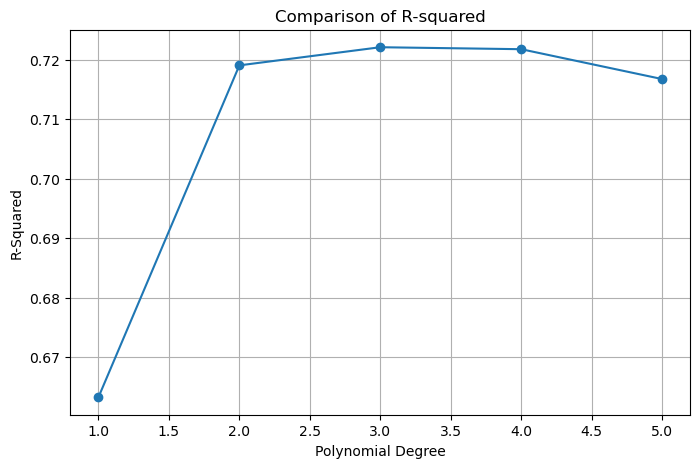

In [52]:
plt.figure(figsize =(8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R-Squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-Squared")
plt.title("Comparison of R-squared")

plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize = (8, 5))


plt.bar_label(bars,fmt='%.2f', padding=3)

plt.xlabel("Polynomial degree